In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Задача 1. Минимизация квадрата отклонения

Рассмотрим задачу:

$$
\min_{\theta} \mathbb{E} |X - \theta|^2
$$

**Решение**


Пусть $F(x)$ - функция распределения случайной величины $X$.

Рассмотрим функцию:
$$
g(\theta) = \mathbb{E} (X - \theta)^2 = \int_{-\infty}^{\infty} (x - \theta)^2 dF(x)
$$

Продифференцируем по $\theta$:
$$
g'(\theta) = \frac{d}{d\theta} \int_{-\infty}^{\infty} (x - \theta)^2 dF(x) = \int_{-\infty}^{\infty} \frac{d}{d\theta}(x - \theta)^2 dF(x)
$$

Вычислим производную подынтегрального выражения:
$$
\frac{d}{d\theta}(x - \theta)^2 = -2(x - \theta)
$$

Таким образом:
$$
g'(\theta) = \int_{-\infty}^{\infty} -2(x - \theta) dF(x) = -2\int_{-\infty}^{\infty} x dF(x) + 2\theta\int_{-\infty}^{\infty} dF(x)
$$

Учитывая, что:
- $\int_{-\infty}^{\infty} x dF(x) = \mathbb{E}[X]$ (математическое ожидание)
- $\int_{-\infty}^{\infty} dF(x) = 1$

Получаем:
$$
g'(\theta) = -2\mathbb{E}[X] + 2\theta
$$

Приравниваем производную к нулю для нахождения минимума:
$$
-2\mathbb{E}[X] + 2\theta = 0 \quad \Rightarrow \quad \theta = \mathbb{E}[X]
$$

Это означает, что оптимальное значение $\theta$ является **математическим ожиданием** распределения.


## Задача 2. Минимизация модуля отклонения от параметра

Рассмотрим распределение $P$ и случайную величину $X \sim P$. Найди $$\min_{\theta} \mathbb{E} |X - \theta|.$$

Прокомментируй результат.

**Решение**


Рассмотрим задачу:
$$
\min_{\theta} \mathbb{E} |X - \theta|
$$


Пусть $F(x)$ - функция распределения случайной величины $X$.

Рассмотрим функцию:
$$
g(\theta) = \mathbb{E} |X - \theta| = \int_{-\infty}^{\infty} |x - \theta| dF(x)
$$

Продифференцируем по $\theta$:
$$
g'(\theta) = \frac{d}{d\theta} \int_{-\infty}^{\infty} |x - \theta| dF(x) = \int_{-\infty}^{\infty} \frac{d}{d\theta}|x - \theta| dF(x)
$$

Заметим, что:
$$
\frac{d}{d\theta}|x - \theta| = \begin{cases}
-1, & \text{если } x > \theta \\\\
1, & \text{если } x < \theta \\\\
\text{не определена}, & \text{если } x = \theta
\end{cases}
$$

Таким образом:
$$
g'(\theta) = \int_{-\infty}^{\theta} 1 dF(x) - \int_{\theta}^{\infty} 1 dF(x) = F(\theta) - (1 - F(\theta)) = 2F(\theta) - 1
$$

Приравниваем производную к нулю для нахождения минимума:
$$
2F(\theta) - 1 = 0 \quad \Rightarrow \quad F(\theta) = \frac{1}{2}
$$

Это означает, что оптимальное значение $\theta$ является **медианой** распределения.

# Задача 3. Медиана vs среднее в качестве оценок матожидания нормального распределения. Симуляция

Рассмотрим нормальное распределение

$$
X \sim \mathcal{N}(\mu,\sigma^2),
$$

где

$$
\mu=1,
\qquad
\sigma^2=2.
$$

По выборке

$$
X_1,X_2,\ldots,X_n
$$

будем оценивать математическое ожидание $\mu$ двумя способами:

$$
\hat{\mu}_1=\overline{X}=
\frac{X_1+\ldots+X_n}{n},
$$

$$
\hat{\mu}_2=\operatorname{median}(X_1,\ldots,X_n).
$$

Проведи симуляцию для разных размеров выборки:

$$
n \in [10,20,30,50,70,100,200,300,500,1000,5000].
$$

Для каждого размера выборки сгенерируй $1000$ выборок и вычисли:

* среднее значение каждой оценки;
* отклонение среднего значения оценки от $\mu$;
* дисперсию оценок;
* среднюю абсолютную ошибку;
* среднеквадратичную ошибку.

Сравни, как качество выборочного среднего и выборочной медианы меняется при увеличении $n$.

**Задание**

1. Проведи симуляцию для всех заданных значений $n$.
2. Построй график зависимости абсолютного смещения от $n$.
3. Построй график зависимости дисперсии от $n$.
4. Построй график зависимости средней абсолютной ошибки от $n$.
5. Сделай выводы:

   * являются ли оценки несмещёнными;
   * являются ли они состоятельными;
   * какая оценка имеет меньшую дисперсию;
   * сближаются ли среднее и медиана по качеству при росте $n$.


In [ ]:
np.random.seed(42)

In [ ]:
mu = 1
sigma = np.sqrt(2)

sample_sizes = [10,20,30,50,70,100,200,300,500,1000,5000]
simulations = 1000

In [ ]:
results = []

for n in sample_sizes:

    mean_estimates = []
    median_estimates = []

    for _ in range(simulations):
        sample = np.random.normal(mu, sigma, n)

        mean_estimates.append(np.mean(sample))
        median_estimates.append(np.median(sample))

    mean_estimates = np.array(mean_estimates)
    median_estimates = np.array(median_estimates)

    results.append({
        "n": n,
        "Оценка": "Среднее",
        "Среднее значение": np.mean(mean_estimates),
        "Абсолютное смещение": abs(np.mean(mean_estimates) - mu),
        "Дисперсия": np.var(mean_estimates),
        "Средняя абсолютная ошибка": np.mean(abs(mean_estimates - mu)),
        "MSE": np.mean((mean_estimates - mu) ** 2)
    })

    results.append({
        "n": n,
        "Оценка": "Медиана",
        "Среднее значение": np.mean(median_estimates),
        "Абсолютное смещение": abs(np.mean(median_estimates) - mu),
        "Дисперсия": np.var(median_estimates),
        "Средняя абсолютная ошибка": np.mean(abs(median_estimates - mu)),
        "MSE": np.mean((median_estimates - mu) ** 2)
    })

In [ ]:
results_df = pd.DataFrame(results)

results_df.round(5)

,n,Оценка,Среднее значение,Абсолютное смещение,Дисперсия,Средняя абсолютная ошибка,MSE
0,10,Среднее,0.99698,0.00302,0.19700,0.35168,0.19701
1,10,Медиана,0.98723,0.01277,0.26731,0.41255,0.26747
2,20,Среднее,1.00076,0.00076,0.09554,0.24600,0.09554
3,20,Медиана,1.00177,0.00177,0.13391,0.29433,0.13391
4,30,Среднее,1.00033,0.00033,0.07191,0.21270,0.07191
5,30,Медиана,1.00384,0.00384,0.10791,0.26206,0.10793
6,50,Среднее,1.00604,0.00604,0.04203,0.16162,0.04206
7,50,Медиана,1.00188,0.00188,0.06201,0.19743,0.06201
8,70,Среднее,1.00268,0.00268,0.02849,0.13298,0.02850
9,70,Медиана,1.00194,0.00194,0.04388,0.16594,0.04388


In [ ]:
mean_results = results_df[results_df["Оценка"] == "Среднее"]
median_results = results_df[results_df["Оценка"] == "Медиана"]

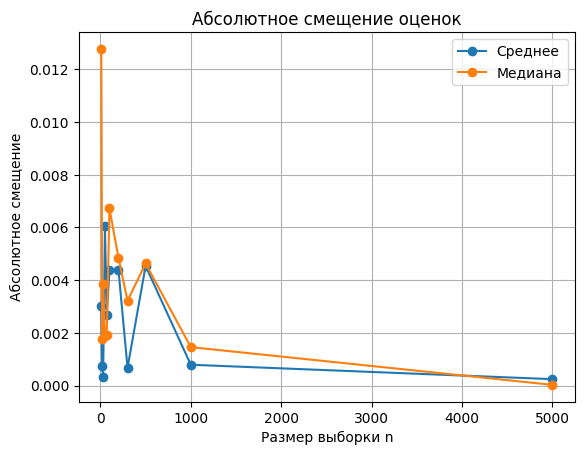

In [ ]:
plt.plot(
    mean_results["n"],
    mean_results["Абсолютное смещение"],
    marker="o",
    label="Среднее"
)

plt.plot(
    median_results["n"],
    median_results["Абсолютное смещение"],
    marker="o",
    label="Медиана"
)

plt.xlabel("Размер выборки n")
plt.ylabel("Абсолютное смещение")
plt.title("Абсолютное смещение оценок")
plt.legend()
plt.grid()
plt.show()

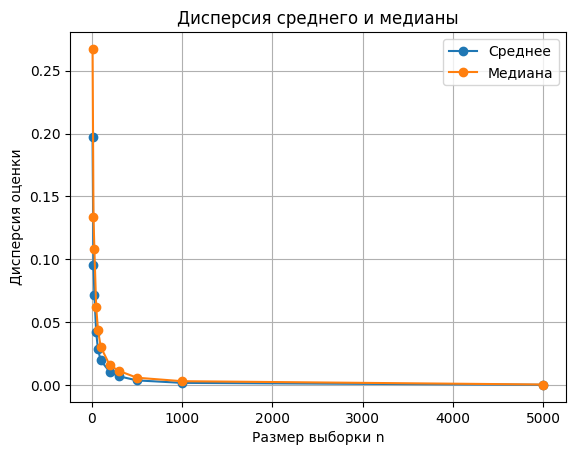

In [ ]:
plt.plot(
    mean_results["n"],
    mean_results["Дисперсия"],
    marker="o",
    label="Среднее"
)

plt.plot(
    median_results["n"],
    median_results["Дисперсия"],
    marker="o",
    label="Медиана"
)

plt.xlabel("Размер выборки n")
plt.ylabel("Дисперсия оценки")
plt.title("Дисперсия среднего и медианы")
plt.legend()
plt.grid()
plt.show()

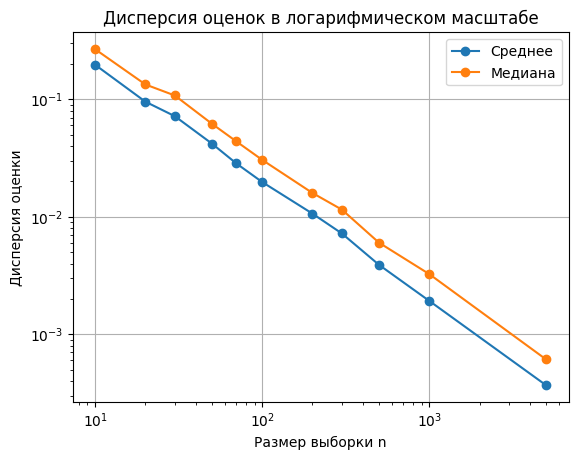

In [ ]:
plt.plot(
    mean_results["n"],
    mean_results["Дисперсия"],
    marker="o",
    label="Среднее"
)

plt.plot(
    median_results["n"],
    median_results["Дисперсия"],
    marker="o",
    label="Медиана"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Размер выборки n")
plt.ylabel("Дисперсия оценки")
plt.title("Дисперсия оценок в логарифмическом масштабе")
plt.legend()
plt.grid()
plt.show()

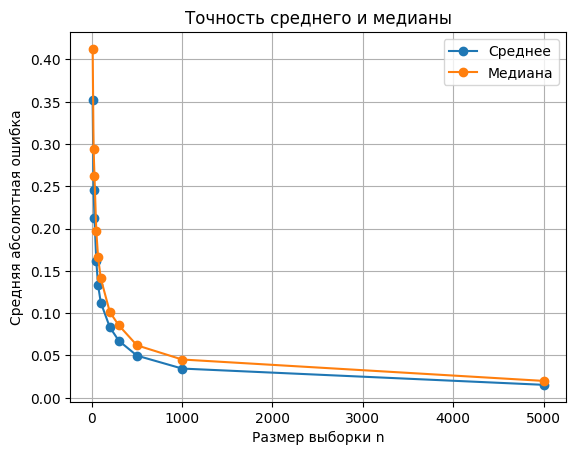

In [ ]:
plt.plot(
    mean_results["n"],
    mean_results["Средняя абсолютная ошибка"],
    marker="o",
    label="Среднее"
)

plt.plot(
    median_results["n"],
    median_results["Средняя абсолютная ошибка"],
    marker="o",
    label="Медиана"
)

plt.xlabel("Размер выборки n")
plt.ylabel("Средняя абсолютная ошибка")
plt.title("Точность среднего и медианы")
plt.legend()
plt.grid()
plt.show()

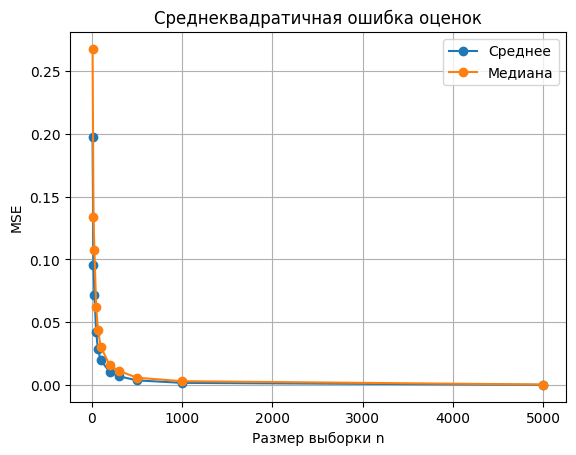

In [ ]:
plt.plot(
    mean_results["n"],
    mean_results["MSE"],
    marker="o",
    label="Среднее"
)

plt.plot(
    median_results["n"],
    median_results["MSE"],
    marker="o",
    label="Медиана"
)

plt.xlabel("Размер выборки n")
plt.ylabel("MSE")
plt.title("Среднеквадратичная ошибка оценок")
plt.legend()
plt.grid()
plt.show()

# Задача 4. Эффективная и неэффективная оценки интенсивности

Пусть $X_i$ — число обращений в поддержку за один час, причём

$$
X_1,\ldots,X_n\overset{\mathrm{iid}}{\sim}\operatorname{Pois}(\lambda),
$$

где $\lambda>0$ — неизвестное среднее число обращений за час.

Для одного наблюдения

$$
\mathbb{P}_\lambda(X=x)=\frac{\lambda^x e^{-\lambda}}{x!},\qquad x=0,1,2,\ldots
$$

Рассмотрим две оценки одного и того же параметра:

$$
\widehat\lambda_1=\overline X,
\qquad
\widehat\lambda_2=X_1.
$$

Нужно:

1. Найти score $U_\lambda(X)$.
2. Найти $I_1(\lambda)$ и $I_n(\lambda)$.
3. Выписать границу Рао–Крамера.
4. Проверить несмещённость обеих оценок.
5. Найти дисперсии $\widehat\lambda_1$ и $\widehat\lambda_2$.
6. Определить, какая оценка эффективна.
7. Найти коэффициенты эффективности обеих оценок.
8. Провести расчёты при $\lambda=9$, $n=36$.

**Решение**

## Пункт 1. Score

Логарифм функции вероятности одного наблюдения:

$$
\log \mathbb{P}_\lambda(X=x)=x\log\lambda-\lambda-\log(x!).
$$

Дифференцируем по $\lambda$:

$$
\frac{\partial}{\partial\lambda}(x\log\lambda)=\frac{x}{\lambda},
\qquad
\frac{\partial}{\partial\lambda}(-\lambda)=-1.
$$

Слагаемое $-\log(x!)$ от $\lambda$ не зависит.

Поэтому

$$
\boxed{U_\lambda(X)=\frac{X}{\lambda}-1=\frac{X-\lambda}{\lambda}}.
$$

## Пункт 2. Информация Фишера

По определению

$$
I_1(\lambda)=\mathbb{E}[U_\lambda(X)^2].
$$

Подставляем score:

$$
I_1(\lambda)=\mathbb{E}\left[\frac{(X-\lambda)^2}{\lambda^2}\right]
=\frac{\mathbb{E}[(X-\lambda)^2]}{\lambda^2}.
$$

Для распределения Пуассона

$$
\mathbb{E}[X]=\lambda,
\qquad
\operatorname{Var}(X)=\lambda.
$$

Следовательно,

$$
\mathbb{E}[(X-\lambda)^2]=\lambda,
$$

и

$$
\boxed{I_1(\lambda)=\frac{1}{\lambda}}.
$$

Во всей выборке

$$
\boxed{I_n(\lambda)=\frac{n}{\lambda}}.
$$

## Пункт 3. Граница Рао–Крамера

Для любой несмещённой оценки $\lambda$:

$$
\operatorname{Var}(\widehat\lambda)\geq\frac{1}{I_n(\lambda)}.
$$

Значит,

$$
\boxed{\operatorname{Var}(\widehat\lambda)\geq\frac{\lambda}{n}}.
$$

## Пункт 4. Несмещённость оценок

Для первой оценки

$$
\mathbb{E}[\widehat\lambda_1]
=\mathbb{E}[\overline X]
=\lambda.
$$

Для второй оценки

$$
\mathbb{E}[\widehat\lambda_2]
=\mathbb{E}[X_1]
=\lambda.
$$

Обе оценки несмещённые.

Важно: **несмещённость сама по себе ещё не означает эффективность**.

## Пункт 5. Дисперсии оценок

Для среднего по всей выборке

$$
\operatorname{Var}(\widehat\lambda_1)
=\operatorname{Var}(\overline X)
=\frac{\lambda}{n}.
$$

Вторая оценка использует только первое наблюдение:

$$
\operatorname{Var}(\widehat\lambda_2)
=\operatorname{Var}(X_1)
=\lambda.
$$

При $n>1$ первая оценка имеет меньшую дисперсию в $n$ раз.

## Пункт 6. Какая оценка эффективна

Граница Рао–Крамера равна

$$
\frac{\lambda}{n}.
$$

Для $\widehat\lambda_1$:

$$
\operatorname{Var}(\widehat\lambda_1)=\frac{\lambda}{n}.
$$

Она достигает границы, значит

$$
\boxed{\widehat\lambda_1=\overline X\text{ эффективна}.}
$$

Для $\widehat\lambda_2$ при $n>1$:

$$
\operatorname{Var}(\widehat\lambda_2)=\lambda>\frac{\lambda}{n}.
$$

Поэтому

$$
\boxed{\widehat\lambda_2=X_1\text{ неэффективна}.}
$$

## Пункт 7. Коэффициент эффективности

Используем

$$
\operatorname{Eff}(\widehat\lambda)
=\frac{1/I_n(\lambda)}{\operatorname{Var}(\widehat\lambda)}.
$$

Для $\widehat\lambda_1$:

$$
\operatorname{Eff}(\widehat\lambda_1)
=\frac{\lambda/n}{\lambda/n}=1.
$$

Для $\widehat\lambda_2$:

$$
\operatorname{Eff}(\widehat\lambda_2)
=\frac{\lambda/n}{\lambda}=\frac{1}{n}.
$$

То есть вторая оценка остаётся несмещённой, но использует информацию из выборки крайне неэффективно.

## Пункт 8. Проверка на числах

Пусть $\lambda=9$, $n=36$.

Информация Фишера во всей выборке:

$$
I_n(\lambda)=\frac{36}{9}=4.
$$

Граница Рао–Крамера:

$$
\frac{1}{I_n(\lambda)}=\frac{1}{4}=0.25.
$$

Для среднего:

$$
\operatorname{Var}(\widehat\lambda_1)=\frac{9}{36}=0.25,
\qquad
\operatorname{Eff}(\widehat\lambda_1)=1.
$$

Для одного наблюдения:

$$
\operatorname{Var}(\widehat\lambda_2)=9,
\qquad
\operatorname{Eff}(\widehat\lambda_2)=\frac{1}{36}.
$$

Обе оценки в среднем попадают в $\lambda$, но их точность при фиксированном $n$ очень разная.